In [5]:
import os
from matplotlib.ticker import FuncFormatter
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import ast
import numpy as np

In [6]:
# --- 설정 ---
result_dir = '/Users/taeyoon/Desktop/KubeCaps/exp_figure10_24hx2/region/integrated'
font_label = 32
font_tick = 32
font_legend = 28
font_family = 'Roboto'
plt.rcParams['font.family'] = font_family
plt.rcParams['font.weight'] = 400
plt.rcParams["axes.labelweight"] = 400
plt.rcParams['axes.unicode_minus'] = False


# --- 분류 함수 ---
def classify_load(row):
    pods, cpu, mem = row['pods'], row['cpu'], row['memory']
    total_cpu = pods * cpu
    total_mem = pods * mem
    if total_cpu <= 200 and total_mem <= 200:
        return 'Low Load'
    elif total_cpu <= 800 and total_mem <= 4000:
        return 'Medium Load'
    else:
        return 'High Load'

# --- Availability 계산 ---
def get_total_nodes(entry):
    nodepool = entry if isinstance(entry, list) else entry.get('nodepool') if isinstance(entry, dict) else None
    parsed = ast.literal_eval(nodepool) if isinstance(nodepool, str) else nodepool if isinstance(nodepool, list) else []
    # print(item.get('num_instances', 0) for item in parsed)
    # print(list(item.get('num_instances', 0) for item in parsed if isinstance(item, dict)))
    return list(item.get('num_instances', 0) for item in parsed if isinstance(item, dict))

# --- UsagePerT3 계산 ---
def get_usage_per_t3(entry):
    nodepool = entry if isinstance(entry, list) else entry.get('nodepool') if isinstance(entry, dict) else None
    parsed = ast.literal_eval(nodepool) if isinstance(nodepool, str) else nodepool if isinstance(nodepool, list) else []
    usage_sum, count = 0, 0
    for item in parsed:
        if isinstance(item, dict) and 'T3' in item and item['T3'] > 0:
            usage_sum += item.get('num_instances', 0) / item['T3']
            count += 1
    return usage_sum / count if count else np.nan

# --- 데이터 로딩 및 전처리 ---
all_dfs = []
for csv_file in os.listdir(result_dir):
    if csv_file.endswith('.csv'):
        df = pd.read_csv(os.path.join(result_dir, csv_file))
        all_dfs.append(df)
if not all_dfs:
    raise ValueError('No CSV files found in the directory.')
result_df = pd.concat(all_dfs, ignore_index=True)
print(result_df.head())

def safe_eval(s):
    if not isinstance(s, str):
        return s
    s = s.replace('nan', 'np.nan').replace('inf', 'np.inf').replace('-np.nan', 'np.nan').replace('-inf', '-np.inf')
    try:
        return eval(s, {"np": np, "__builtins__": {}})
    except:
        return {}

if isinstance(result_df['karpenter'].iloc[0], str):
    result_df['karpenter'] = result_df['karpenter'].apply(safe_eval)
    result_df['kubecaps'] = result_df['kubecaps'].apply(safe_eval)

karpenter_df = result_df['karpenter'].apply(pd.Series).add_prefix('karpenter_')
kubecaps_df = result_df['kubecaps'].apply(pd.Series).add_prefix('kubecaps_')
result_df = pd.concat([result_df, karpenter_df, kubecaps_df], axis=1)

result_df['load_category'] = result_df.apply(classify_load, axis=1)
filtered_df = result_df[result_df['karpenter_excess_pod'].fillna(0).astype(float) >= 0]

# --- 각 부하별 처리 ---
load_categories = {
    'Low': filtered_df[filtered_df['load_category'] == 'Low Load'],
    'Medium': filtered_df[filtered_df['load_category'] == 'Medium Load'],
    'High': filtered_df[filtered_df['load_category'] == 'High Load'],
}

def flatten(lst):
    result = []
    for item in lst:
        if isinstance(item, list):
            result.extend(flatten(item))
        else:
            result.append(item)
    return result

                        time  pods  cpu  memory  \
0  2025-08-20 14:00:00+09:00    10    1       1   
1  2025-08-20 14:00:00+09:00    10    1       2   
2  2025-08-23 11:00:00+09:00    10    1       1   
3  2025-08-23 11:00:00+09:00    10    1       2   
4  2025-08-23 11:00:00+09:00    10    1       4   

                                           karpenter  \
0  {'performance': np.float64(385375.1046336001),...   
1  {'performance': np.float64(385375.1046336001),...   
2  {'performance': np.float64(385375.1046336001),...   
3  {'performance': np.float64(385375.1046336001),...   
4  {'performance': np.float64(388753.48040959996)...   

                                            kubecaps     region  
0  {'performance': 183578.9179, 'cost': 0.0288000...  us-west-2  
1  {'performance': 333149.00488799997, 'cost': 0....  us-west-2  
2  {'performance': 183578.9179, 'cost': 0.028, 'a...  us-west-2  
3  {'performance': 333149.00488799997, 'cost': 0....  us-west-2  
4  {'performance': 337135.

KubeCAPS 평균: 8.025212902751596
Karpenter 평균: 11.72919129708771
KubeCAPS 비용 절감율: 31.58%


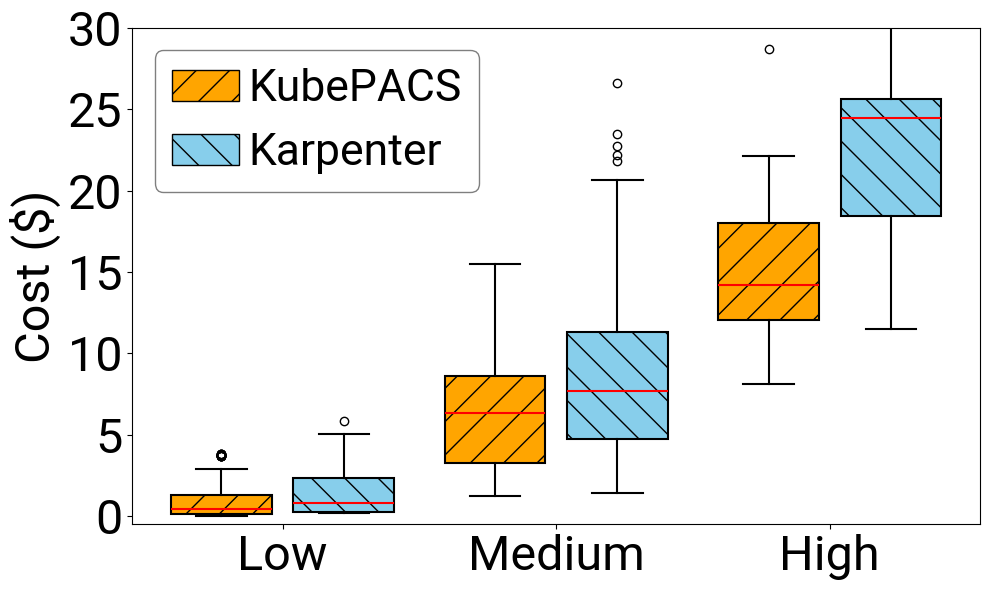

KubeCAPS 평균: 29946.448738690422
Karpenter 평균: 26750.55707552737
KubeCAPS 성능 향상율: 11.95%


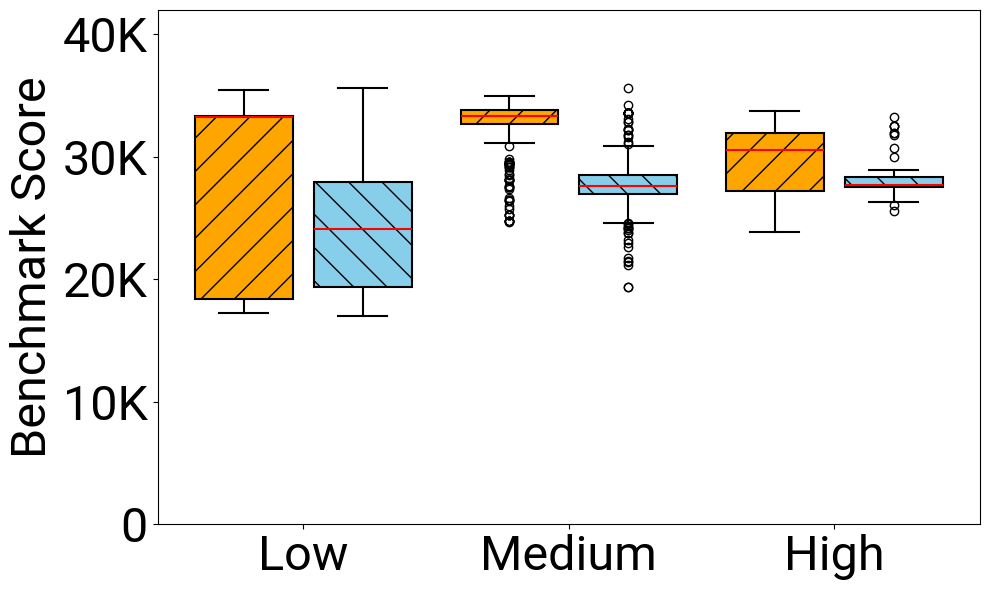

KubeCAPS 평균: 12.269201754404028
Karpenter 평균: 1.2772780795291347
KubeCAPS 성능 향상율: 860.57%


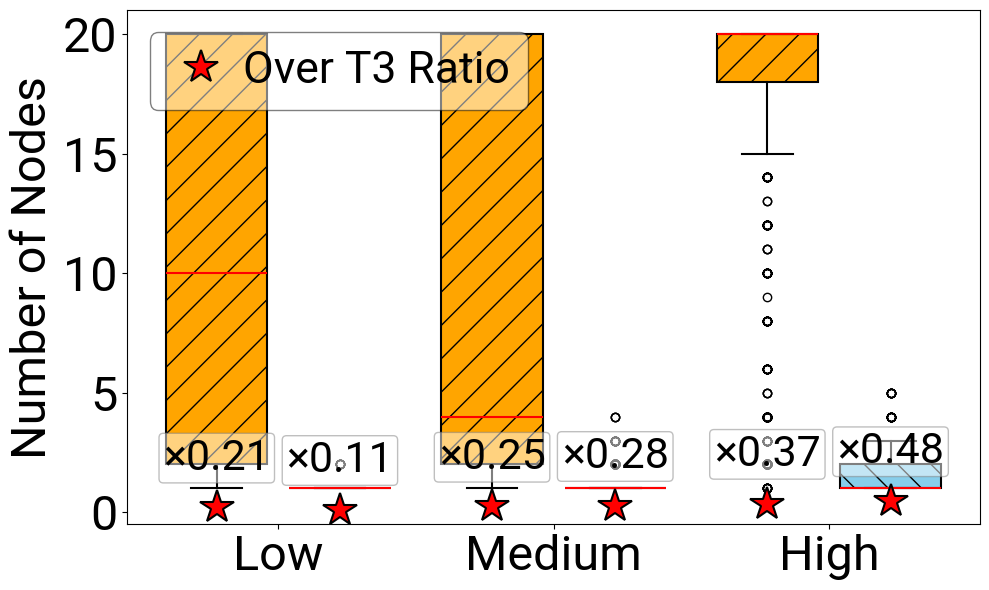

모든 그림 생성이 완료되었습니다.


In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import os
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
import numpy as np

# === 기본 설정 ===
font_size = 35
result_dir = "./"  # 저장 경로 지정
metrics = ['Cost', 'Performance', 'Availability']
load_order = ['Low', 'Medium', 'High']

# === K 단위 포맷터 ===
def kilo_formatter(x, pos):
    return f"{int(x/1e3)}K" if x >= 1e3 else f"{int(x)}"

# === 간격 설정 ===
base_gap = 1.9      # 카테고리 간 간격
intra_gap = 0.85     # 같은 카테고리 내 박스 간 간격

for metric_name in metrics:
    fig, ax = plt.subplots(figsize=(10, 6))

    all_kubecaps_data = []
    all_karpenter_data = []
    all_kubecaps_t3_ratio_means = []
    all_karpenter_t3_ratio_means = []

    for i, load_name in enumerate(load_order):
        load_df = load_categories[load_name]

        if metric_name == 'Cost':
            kubecaps_data = load_df['kubecaps_cost']
            karpenter_data = load_df['karpenter_cost']
            ax.set_ylim(-0.5, 3)
            ax.set_yticks([0, 5, 10, 15, 20, 25, 30])
            ax.set_ylabel('Cost ($)', fontsize=font_size, labelpad=5)

        elif metric_name == 'Performance':
            kubecaps_data = load_df['kubecaps_performance'] / load_df['kubecaps_actual_pods']
            karpenter_data = load_df['karpenter_performance'] / load_df['karpenter_assignable_pod']
            ax.set_ylim(9000, 42000)
            ax.set_yticks([0, 10000, 20000, 30000, 40000])
            ax.yaxis.set_major_formatter(FuncFormatter(kilo_formatter))
            ax.set_ylabel('Benchmark Score', fontsize=font_size, labelpad=5)

        elif metric_name == 'Availability':
            karp_avail = load_df['karpenter'].apply(get_total_nodes)
            kube_avail = load_df['kubecaps'].apply(get_total_nodes)
            karpenter_data = flatten(list(karp_avail))
            kubecaps_data = flatten(list(kube_avail))

            karp_mean_t3 = load_df['karpenter'].apply(get_usage_per_t3).mean()
            kube_mean_t3 = load_df['kubecaps'].apply(get_usage_per_t3).mean()
            all_karpenter_t3_ratio_means.append(karp_mean_t3)
            all_kubecaps_t3_ratio_means.append(kube_mean_t3)

            ax.set_ylim(-0.5, 21)
            ax.set_yticks([0, 5, 10, 15, 20])
            ax.set_ylabel('Number of Nodes', fontsize=font_size, labelpad=5)

        all_kubecaps_data.append(kubecaps_data)
        all_karpenter_data.append(karpenter_data)
    mean_all_kubecaps_data = np.mean([np.mean(kubecaps_data) for kubecaps_data in all_kubecaps_data])
    mean_all_karpenter_data = np.mean([np.mean(karpenter_data) for karpenter_data in all_karpenter_data])

    print(f"KubeCAPS 평균: {mean_all_kubecaps_data}")
    print(f"Karpenter 평균: {mean_all_karpenter_data}")

    if metric_name == 'Cost':
        improvement_percentage = ((mean_all_karpenter_data - mean_all_kubecaps_data) / mean_all_karpenter_data) * 100
        print(f"KubeCAPS 비용 절감율: {improvement_percentage:.2f}%")
    else:
        improvement_percentage = ((mean_all_kubecaps_data - mean_all_karpenter_data) / mean_all_karpenter_data) * 100
        print(f"KubeCAPS 성능 향상율: {improvement_percentage:.2f}%")

    # 간격 조정된 포지션
    positions_kubecaps = [i * base_gap for i in range(len(load_order))]
    positions_karpenter = [i * base_gap + intra_gap for i in range(len(load_order))]
    xtick_positions = [i * base_gap + intra_gap / 2 for i in range(len(load_order))]

    # Boxplot 생성
    bp1 = ax.boxplot(
        [d for pair in zip(all_kubecaps_data, all_karpenter_data) for d in pair],
        positions=sorted(positions_kubecaps + positions_karpenter),
        widths=0.7,
        patch_artist=True,
        manage_ticks=False
    )

    # 색상 및 해치
    for i, patch in enumerate(bp1['boxes']):
        if i % 2 == 0:
            patch.set_facecolor('orange')
            patch.set_hatch('/')
        else:
            patch.set_facecolor('skyblue')
            patch.set_hatch('\\')
        patch.set_edgecolor('black')
        patch.set_linewidth(1.5)

    for median in bp1['medians']:
        median.set(color='red', linewidth=1.5)

    for l_type in ['whiskers', 'caps', 'fliers']:
        for artist in bp1[l_type]:
            artist.set_color('black')
            artist.set_linewidth(1.5)

    # x축 설정
    ax.tick_params(axis='y', labelsize=font_size)
    ax.set_xticks(xtick_positions)
    ax.set_xticklabels(load_order, fontsize=font_size)

    # Availability: Over T3 Ratio 마커
    if metric_name == 'Availability':
        offset = 1.2
        for i in range(len(load_order)):
            ax.plot(positions_kubecaps[i], all_kubecaps_t3_ratio_means[i],
                    marker='*', color='red', markersize=25,
                    markeredgecolor='black', markeredgewidth=1.5, zorder=100)
            ax.plot(positions_karpenter[i], all_karpenter_t3_ratio_means[i],
                    marker='*', color='red', markersize=25,
                    markeredgecolor='black', markeredgewidth=1.5, zorder=100)

            ax.text(
                positions_kubecaps[i], all_kubecaps_t3_ratio_means[i] + offset,
                f"×{all_kubecaps_t3_ratio_means[i]:.2f}", fontsize=font_size - 4,
                va='bottom', ha='center',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.5, edgecolor='gray')
            )
            ax.text(
                positions_karpenter[i], all_karpenter_t3_ratio_means[i] + offset,
                f"×{all_karpenter_t3_ratio_means[i]:.2f}", fontsize=font_size - 4,
                va='bottom', ha='center',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.5, edgecolor='gray')
            )

    # 범례 설정
    legend_elements = [
        Patch(facecolor='orange', edgecolor='black', label='KubePACS', hatch='/'),
        Patch(facecolor='skyblue', edgecolor='black', label='Karpenter', hatch='\\')
    ]
    if metric_name == 'Availability':
        legend_elements.append(Line2D([0], [0], marker='*', color='w', label='Over T3 Ratio',
                                      markerfacecolor='red', markersize=25,
                                      markeredgecolor='black', markeredgewidth=1.5, linestyle='None'))
    if metric_name == 'Cost':
        ax.legend(
            handles=legend_elements,
            fontsize=font_size - 3,
            loc='upper left',
            handlelength=1.5,
            handletextpad=0.2,
            edgecolor='black',
            framealpha=0.5,
            ncol=1
        )
    elif metric_name == 'Availability':
        ax.legend(
            handles=[legend_elements[-1]],
            fontsize=font_size - 3,
            loc='upper left',
            handlelength=1.5,
            handletextpad=0.2,
            edgecolor='black',
            framealpha=0.5,
            ncol=1
        )


    plt.tight_layout()
    plt.savefig(os.path.join(result_dir, f"karpenter_vs_kubecaps_{metric_name.lower()}.pdf"), bbox_inches='tight')
    plt.show()
    plt.close(fig)

print("모든 그림 생성이 완료되었습니다.")


In [8]:
mean_kubecaps_efficiency = load_df["kubecaps_efficiency"].mean()
mean_karpenter_efficiency = load_df["karpenter_efficiency"].mean()

print(mean_kubecaps_efficiency)
print(mean_karpenter_efficiency)
improvement_percentage = ((mean_kubecaps_efficiency - mean_karpenter_efficiency) / mean_karpenter_efficiency) * 100
print(f"KubePACS가 Karpenter보다 {improvement_percentage}% 더 효율적입니다.")


1973.226501101787
1366.9863190747874
KubePACS가 Karpenter보다 44.34866491109576% 더 효율적입니다.
